# SEMANA 12: DISTRIBUCIONES DE PROBABILIDAD A PRIORI Y POSTERIORI

## 1. Con la información tomada del siguiente artículo sobre niveles de obesidad (https://www.sciencedirect.com/science/article/pii/S2352340919306985aea), en la cual se quiere predecir estos para una persona y que contiene tres variables numéricas (‘Age’, ‘Height’ y ‘Weight’) siendo el resto categóricas, haga lo siguiente:

### a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, y balanceo de clases.

In [84]:
import pandas as pd
df=pd.read_csv("obesidad.csv",sep=",")
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.4,yes,yes,3,3,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,22,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,23,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24,1.74,133.3,yes,yes,3,3,Sometimes,no,3,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III


In [86]:
# Verificar valores faltantes
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [88]:
# Función para detectar outliers usando IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Detectar outliers para las variables numéricas
outliers_age = detect_outliers(df, 'Age')
outliers_height = detect_outliers(df, 'Height')
outliers_weight = detect_outliers(df, 'Weight')

# Ver cuántos outliers hay en cada columna
print(f'Outliers en Age: {len(outliers_age)}')
print(f'Outliers en Height: {len(outliers_height)}')
print(f'Outliers en Weight: {len(outliers_weight)}')


Outliers en Age: 160
Outliers en Height: 0
Outliers en Weight: 1


In [90]:
# Eliminar los outliers
df_clean = df[~df['Age'].isin(outliers_age['Age'])]
df_clean = df_clean[~df_clean['Weight'].isin(outliers_weight['Weight'])]

# Verificar cuántos registros quedan después de eliminar los outliers
print(f"Datos después de eliminar outliers: {df_clean.shape[0]}")

Datos después de eliminar outliers: 1950


In [92]:
from scipy.stats import zscore

# Calcular el Z-score para las columnas numéricas
df['Age_zscore'] = zscore(df['Age'])
df['Height_zscore'] = zscore(df['Height'])
df['Weight_zscore'] = zscore(df['Weight'])

# Filtrar los valores con Z-score fuera del rango [-3, 3]
df = df[(df['Age_zscore'].abs() < 3) & (df['Height_zscore'].abs() < 3) & (df['Weight_zscore'].abs() < 3)]
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,Age_zscore,Height_zscore,Weight_zscore
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,-0.521741,-0.874380,-0.862555
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,-0.521741,-1.945660,-1.168074
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,-0.207057,1.053924,-0.366087
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,0.422312,1.053924,0.015811
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,-0.364399,0.839668,0.122743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.4,yes,yes,3,3,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Obesity_Type_III,-0.521741,0.089772,1.711441
2107,Female,22,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,-0.364399,0.518284,1.799278
2108,Female,23,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,-0.207057,0.518284,1.799278
2109,Female,24,1.74,133.3,yes,yes,3,3,Sometimes,no,3,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III,-0.049714,0.411156,1.784002


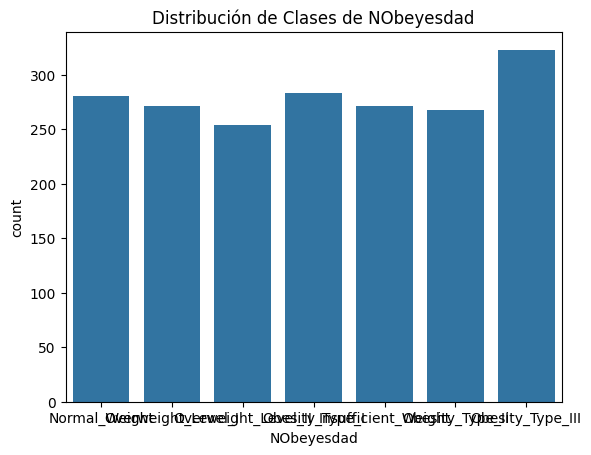

Distribución de clases en NObeyesdad:
NObeyesdad
Obesity_Type_III       323
Obesity_Type_I         283
Normal_Weight          280
Overweight_Level_I     271
Insufficient_Weight    271
Obesity_Type_II        268
Overweight_Level_II    254
Name: count, dtype: int64


In [94]:
#Balanceo de datos
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar la distribución de las clases
sns.countplot(x='NObeyesdad', data=df_clean)
plt.title("Distribución de Clases de NObeyesdad")
plt.show()

# Contar las instancias por clase
class_counts = df_clean['NObeyesdad'].value_counts()
print("Distribución de clases en NObeyesdad:")
print(class_counts)



#### En el proceso de preprocesamiento de los datos, comencé trabajando con un DataFrame que no contenía valores faltantes, lo cual facilitó el análisis. A continuación, me centré en la detección de outliers en las variables numéricas, como Age y Weight. Al analizar los datos, identifiqué valores extremadamente improbables, como personas con 160 años de edad o con un peso de 1 kg pero con obesidad, los cuales no tenían sentido. Por ello, decidí eliminar estos outliers para evitar que afectaran el análisis y modelado. Después de esto, verifiqué la distribución de las clases en la variable objetivo NObeyesdad, y observé que las clases estaban equilibradas, lo que significaba que no era necesario aplicar técnicas de balanceo como SMOTE. Finalmente, el conjunto de datos quedó limpio, sin valores faltantes ni outliers, y listo para ser utilizado en futuros análisis o modelos de Machine Learning.

### b. Convierta las variables categóricas a dummies por medio de la función ‘OneHotEncoder’ de la librería ‘category_encoders’ la cual debe ser previamente instalada mediante la sentencia ‘!pip install category-encoders’.

In [97]:
# Instalar la librería category_encoders
!pip install category-encoders


In [99]:
# Importar la librería
import category_encoders as ce

# Crear el codificador OneHotEncoder
encoder = ce.OneHotEncoder(cols=df_clean.select_dtypes(include=['object']).columns)

# Aplicar el OneHotEncoder
df_encoded = encoder.fit_transform(df_clean)

# Ver las primeras filas del DataFrame con las variables codificadas
df_encoded.head()

,Gender_1,Gender_2,Age,Height,Weight,family_history_with_overweight_1,family_history_with_overweight_2,FAVC_1,FAVC_2,FCVC,...,MTRANS_3,MTRANS_4,MTRANS_5,NObeyesdad_1,NObeyesdad_2,NObeyesdad_3,NObeyesdad_4,NObeyesdad_5,NObeyesdad_6,NObeyesdad_7
0,1,0,21,1.62,64.0,1,0,1,0,2,...,0,0,0,1,0,0,0,0,0,0
1,1,0,21,1.52,56.0,1,0,1,0,3,...,0,0,0,1,0,0,0,0,0,0
2,0,1,23,1.80,77.0,1,0,1,0,2,...,0,0,0,1,0,0,0,0,0,0
3,0,1,27,1.80,87.0,0,1,1,0,3,...,0,0,0,0,1,0,0,0,0,0
4,0,1,22,1.78,89.8,0,1,1,0,2,...,0,0,0,0,0,1,0,0,0,0


#### Para transformar las variables categóricas de mi conjunto de datos, decidí utilizar la librería category_encoders y su función OneHotEncoder. Primero, instalé la librería y luego la apliqué sobre las columnas categóricas del DataFrame. Este codificador convierte cada categoría en una columna binaria (0 o 1), lo que facilita su uso en modelos de Machine Learning que requieren variables numéricas. Así, todas las variables categóricas de tipo "object" se transformaron correctamente en variables dummies. Con esta transformación, ahora tengo un conjunto de datos listo para ser alimentado a un modelo sin que las variables categóricas representen un obstáculo.



### c. Separe los datos en entrenamiento (80%) y prueba (20%), realice un Naive Bayes mediante la función ‘GaussianNB’ y ‘MultinomialNB’. Compare los accuracy para los resultados obtenidos y diga con cuál de ellos se obtuvo un mejor desempeño.


In [104]:
# Separar la variable objetivo antes de la codificación
X = df_clean.drop('NObeyesdad', axis=1)  # Variables independientes
y = df_clean['NObeyesdad']  # Variable dependiente

# Aplicar OneHotEncoder solo a las variables independientes
import category_encoders as ce
encoder = ce.OneHotEncoder(cols=X.select_dtypes(include=['object']).columns)
X_encoded = encoder.fit_transform(X)

# Ahora X_encoded tiene las variables categóricas convertidas a dummies
# Y 'y' es la variable objetivo que no ha sido modificada

# Dividir los datos en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Instanciar y entrenar el modelo Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Hacer predicciones con Gaussian Naive Bayes
y_pred_gnb = gnb.predict(X_test)

# Calcular el accuracy de Gaussian Naive Bayes
from sklearn.metrics import accuracy_score
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Accuracy con Gaussian Naive Bayes: {accuracy_gnb:.4f}")

# Instanciar y entrenar el modelo Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# Hacer predicciones con Multinomial Naive Bayes
y_pred_mnb = mnb.predict(X_test)

# Calcular el accuracy de Multinomial Naive Bayes
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Accuracy con Multinomial Naive Bayes: {accuracy_mnb:.4f}")



Accuracy con Gaussian Naive Bayes: 0.5769
Accuracy con Multinomial Naive Bayes: 0.6487


#### Después de entrenar y evaluar dos modelos de Naive Bayes, GaussianNB y MultinomialNB, sobre mi conjunto de datos, los resultados fueron los siguientes: el modelo Gaussian Naive Bayes obtuvo un accuracy de 57.69%, mientras que el modelo Multinomial Naive Bayes alcanzó un accuracy de 64.87%. Estos resultados sugieren que, en este caso, Multinomial Naive Bayes ofreció un mejor desempeño que Gaussian Naive Bayes. Esto podría deberse a que las características de mi conjunto de datos, especialmente las variables categóricas convertidas en dummies, se ajustan mejor al enfoque del modelo multinomial, que está diseñado para manejar variables discretas. Por lo tanto, el modelo Multinomial Naive Bayes parece ser más adecuado para este tipo de datos, y podría ser una opción más confiable para futuros análisis y predicciones.